Epoch 0, Train Loss: 8.6848, Val Loss: 11.8667
Epoch 500, Train Loss: 0.0937, Val Loss: 0.8645
Epoch 1000, Train Loss: 0.0121, Val Loss: 0.4824
Epoch 1500, Train Loss: 0.0104, Val Loss: 0.4666
Epoch 2000, Train Loss: 0.0092, Val Loss: 0.4707
Epoch 2500, Train Loss: 0.0084, Val Loss: 0.4787


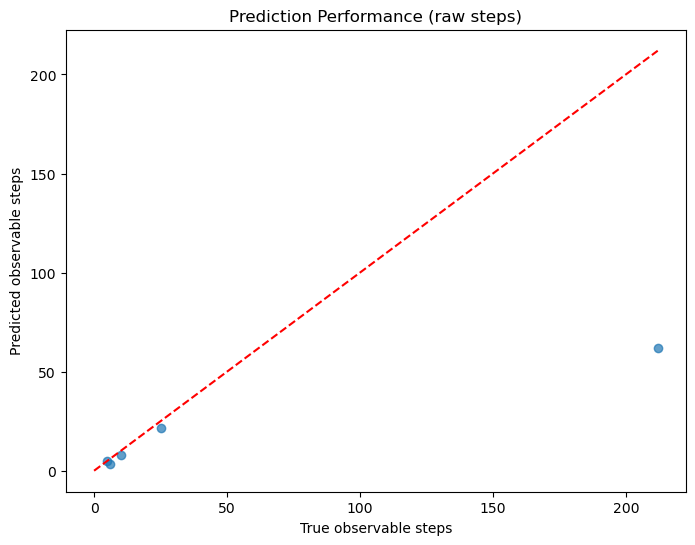

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

df_gpu = pd.read_csv('summary_GPU_lr_scan.csv')
df_npu = pd.read_csv('summary_NPU_lr_scan.csv')

def compute_observable_steps(df, threshold):
    df_both = df[(df['error_mode'] == 'both') & (df['layer_types'].isin(['none', None]))]
    df_none = df[(df['error_mode'] == 'none') & (df['layer_types'].isin(['[]', None]))]
    loss_cols = [col for col in df.columns if col.startswith('loss_iter_')]
    results = []
    for lr in sorted(df_both['learning_rate'].unique()):
        for eps in sorted(df_both['forward_eps'].unique()):
            base_rows = df_none[df_none['learning_rate'] == lr]
            if len(base_rows) == 0:
                continue
            base_mean = base_rows[loss_cols].mean().values
            rows = df_both[(df_both['learning_rate'] == lr) & (df_both['forward_eps'] == eps)]
            if len(rows) == 0:
                continue
            both_mean = rows[loss_cols].mean().values
            loss_diff = both_mean - base_mean
            step = np.argmax(loss_diff > threshold) if np.any(loss_diff > threshold) else np.nan
            results.append({'learning_rate': lr, 'eps': eps, 'observable_steps': step})
    results_df = pd.DataFrame(results)
    results_df['product_lr_eps'] = results_df['learning_rate'] * results_df['eps']
    return results_df.dropna()

threshold = 0.1
gpu_steps = compute_observable_steps(df_gpu, threshold)
npu_steps = compute_observable_steps(df_npu, threshold)

gpu_steps['platform'] = 0
npu_steps['platform'] = 1
all_data = pd.concat([gpu_steps, npu_steps], ignore_index=True)

X = all_data[['learning_rate', 'eps', 'platform']].values
# y = all_data['observable_steps'].values
y = np.log1p(all_data['observable_steps'].values)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# Step 5: Neural network model
class HorizonMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model = HorizonMLP()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Step 6: Training
for epoch in range(3000):
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss = criterion(output, y_train)
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        model.eval()
        val_loss = criterion(model(X_val), y_val).item()
        print(f"Epoch {epoch}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}")

# Step 7: Visualization
model.eval()
with torch.no_grad():
    preds = model(X_val).numpy()

# y_val_flat = y_val.numpy().flatten()
# preds_flat = preds.flatten()

# plt.figure(figsize=(8,6))
# plt.scatter(y_val_flat, preds_flat, alpha=0.7)
# plt.plot([0, max(y_val_flat)], [0, max(y_val_flat)], linestyle='--', color='red')
# plt.xlabel("True observable steps (log-space)")
# plt.ylabel("Predicted observable steps (log-space)")
# plt.title("Prediction Performance")
# plt.show()

# Inverse transform back to raw step count space
y_val_raw = np.expm1(y_val_flat)
preds_raw = np.expm1(preds_flat)

plt.figure(figsize=(8,6))
plt.scatter(y_val_raw, preds_raw, alpha=0.7)
plt.plot([0, max(y_val_raw)], [0, max(y_val_raw)], linestyle='--', color='red')
plt.xlabel("True observable steps")
plt.ylabel("Predicted observable steps")
plt.title("Prediction Performance (raw steps)")
plt.show()

In [7]:
# 测试
test_lr = 6e-4
test_eps = 1e-5
test_platform = 0  # 0 表示 GPU，1 表示 NPU

# 构造成 numpy 数组，维度为 (1, 3)
X_new = np.array([[test_lr, test_eps, test_platform]])

# 使用之前训练用的 scaler 进行标准化
X_new_scaled = scaler.transform(X_new)

# 转换为 torch tensor
X_new_tensor = torch.tensor(X_new_scaled, dtype=torch.float32)

# 进入模型预测
model.eval()
with torch.no_grad():
    y_pred_log = model(X_new_tensor).item()

# 逆变换回真实步数 (注意之前做了 log1p)
y_pred_steps = np.expm1(y_pred_log)

# 输出预测结果
print(f"Predicted observable steps: {y_pred_steps:.2f}")

Predicted observable steps: 6.25


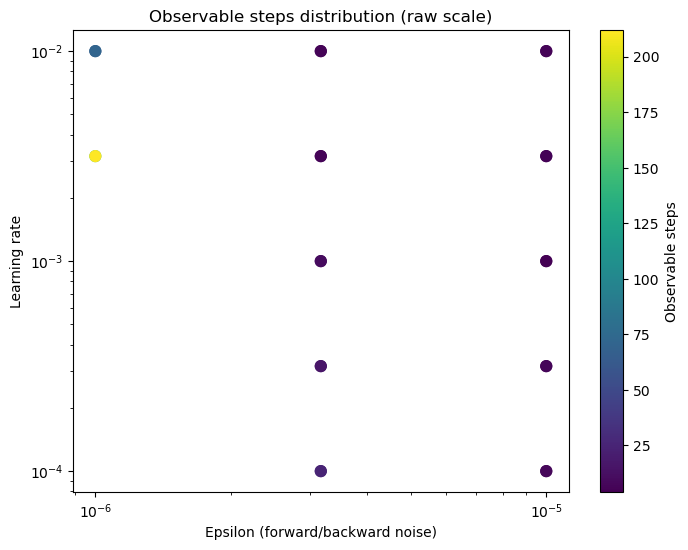

In [8]:
# 直接用你已有的 all_data 数据
plt.figure(figsize=(8,6))
sc = plt.scatter(all_data['eps'], all_data['learning_rate'], 
                 c=all_data['observable_steps'], cmap='viridis', s=60)

plt.colorbar(sc, label='Observable steps')
plt.xlabel("Epsilon (forward/backward noise)")
plt.ylabel("Learning rate")
plt.title("Observable steps distribution (raw scale)")
plt.xscale('log')
plt.yscale('log')
plt.show()